In [1]:
import os
import sys
import torch
import math
import matplotlib.pyplot as plt

# 添加当前目录到路径，确保能导入模块
sys.path.append(os.getcwd())

from drone_dynamics import simulate_position_step, solve_attitude_from_thrust_and_goal_vec
from drone_renderer import DroneRenderer

# 检查 CUDA
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


## 1. 初始化配置与渲染器

建议将物理参数和渲染参数分开配置。
`DroneRenderer` 只需初始化一次。


In [2]:
# --- 配置参数 ---
SIM_CONFIG = {
    'dt': 0.02,
    'batch_size': 2, # 演示 Batch 仿真 (同时模拟两架无人机)
    'mesh_path': os.path.join("data", "sample", "sample.obj"),
    'image_size': (480, 640),
    'camera_pitch': 15.0, # 相机向下倾斜 15 度
}

# --- 初始化渲染器 ---
if os.path.exists(SIM_CONFIG['mesh_path']):
    renderer = DroneRenderer(
        mesh_path=SIM_CONFIG['mesh_path'],
        device=device,
        image_size=SIM_CONFIG['image_size']
    )
    print("Renderer initialized successfully.")
else:
    raise FileNotFoundError(f"Mesh file not found at {SIM_CONFIG['mesh_path']}. Check path.")

Renderer initialized successfully.


## 2. 初始化动力学状态 (ROS 坐标系)

所有状态均维护在 **ROS (ENU)** 坐标系下：
*   位置 `p`: [East, North, Up]
*   速度 `v`: [East, North, Up]
*   姿态 `R`: Body -> World

这里我们初始化两架无人机：
1.  **Drone A**: 悬停在 [0, 0, 2.0]。
2.  **Drone B**: 从 [0, 0, 5.0] 开始，准备向前(East)飞行。


In [3]:
B = SIM_CONFIG['batch_size']

# 1. 位置 (Meters)
# Drone 0: [0, 0, 2]
# Drone 1: [0, 0, 5]
p = torch.tensor([
    [0.0, 0.0, 2.0],
    [0.0, 0.0, 5.0]
], device=device)

# 2. 速度 (m/s)
v = torch.zeros(B, 3, device=device)

# 3. 加速度 (m/s^2)
a = torch.zeros(B, 3, device=device)

# 4. 执行器状态 (Current Actuation / Net Thrust Acc)
# 初始假设处于悬停推力状态 (抵消重力)
# 注意: act 定义为“净”加速度，即 Thrust + Gravity。
# 如果完全悬停，act = 0。Thrust = -Gravity = 9.8 (Up)
act = torch.zeros(B, 3, device=device)

# 5. 姿态 (Rotation Matrix)
# 初始为单位矩阵 (Heading East, Up is Up)
R = torch.eye(3, device=device).unsqueeze(0).repeat(B, 1, 1)

print(f"Initialized state for {B} drones.")


Initialized state for 2 drones.


## 3. 仿真循环 (The Loop)

**最佳实践流程**：
1.  **Planner/Controller**: 决定期望的推力 (`act_pred`)。
2.  **Attitude Dynamics**: 根据推力方向更新机体姿态 (`R`)。
3.  **Position Dynamics**: 根据当前状态和姿态更新位置/速度 (`p`, `v`, `a`)。
4.  **Render Interface**: 将 ROS 状态转换为 PyTorch3D 格式。
5.  **Rendering**: 生成图像。


In [4]:
# --- 模拟控制输入与目标 ---
# Drone 0 (悬停): act_pred = [0, 0, 0]
# Drone 1 (前飞): 向 East 加速. act_pred = [2.0, 0, 0]
act_pred = torch.tensor([
    [0.0, 0.0, 0.0],
    [5.0, 0.0, 2.0]
], device=device)

# --- 定义目标位置 (Look At Points) ---
# Drone 0: 悬停在原点，看着 (10, 10, 2)
# Drone 1: 向东飞，看着正东方远处的 (100, 0, 5)
target_pos = torch.tensor([
    [10.0, 10.0, 2.0],
    [100.0, 0.0, 5.0]
], device=device)

dt = SIM_CONFIG['dt']
steps = 10 

print("Starting simulation loop...")

for step in range(steps):
    # --- A. 姿态更新 (Attitude Update) ---
    g_vec = torch.tensor([0.0, 0.0, 9.8], device=device)
    target_thrust_vec = act_pred + g_vec
    
    # 目标朝向 (Heading): 
    # 用户需求: 机体 X 轴始终对准目标位置 (Face Target mode)
    # 我们计算指向目标的向量，并将其作为 velocity 参数传入
    goal_direction = target_pos - p
    
    # 注意: solve_attitude 会根据 inertia 平滑过渡到 goal_direction
    R_new = solve_attitude_from_thrust_and_goal_vec(
        thrust_vector=target_thrust_vec,
        velocity=goal_direction, # 传入目标方向向量，而非当前速度
        R_old=R,
        dt=dt
    )
    R = R_new # Update State
    
    # --- B. 位置动力学 (Position Dynamics) ---
    p_next, v_next, a_next, act_next = simulate_position_step(
        p=p, v=v, a=a, 
        act=act, act_pred=act_pred, 
        R=R, dt=dt,
        enable_airmode=True
    )
    
    # 更新状态
    p, v, a, act = p_next, v_next, a_next, act_next
    
    # --- C. 渲染 (Rendering) ---
    R_view, T_view = renderer.compute_view_matrix(
        p_ros=p, 
        R_ros=R, 
        camera_pitch_deg=SIM_CONFIG['camera_pitch']
    )
    
    if step == steps - 1:
        rgb_batch, depth_batch = renderer.render(R_view, T_view)
        print(f"Step {step}: Rendered batch shape {rgb_batch.shape}")

print("Simulation finished.")

Starting simulation loop...
Step 9: Rendered batch shape torch.Size([2, 480, 640, 3])
Simulation finished.


## 4. 结果可视化

展示两架无人机在最后时刻的“机上视角”。


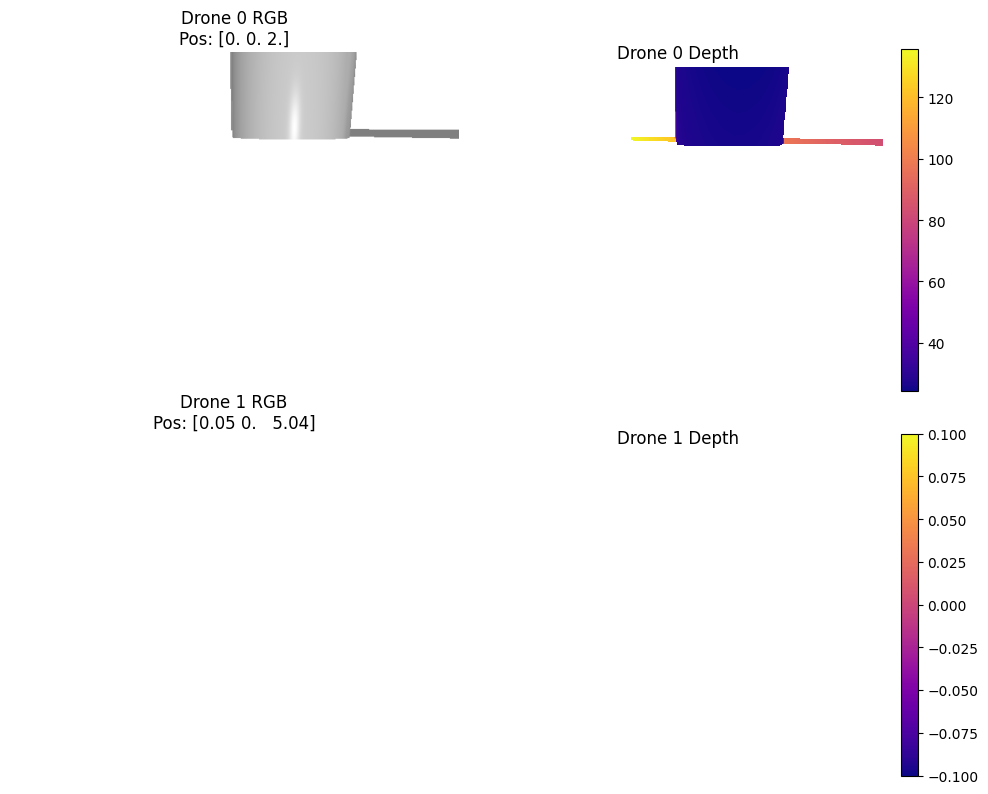

In [5]:
# 可视化最后一步的渲染结果
fig, axes = plt.subplots(B, 2, figsize=(10, 4 * B))

if B == 1:
    axes = axes[None, :]

for i in range(B):
    # RGB
    ax_rgb = axes[i, 0]
    img = rgb_batch[i].cpu().numpy()
    ax_rgb.imshow(img)
    ax_rgb.set_title(f"Drone {i} RGB\nPos: {p[i].cpu().numpy().round(2)}")
    ax_rgb.axis('off')
    
    # Depth
    ax_depth = axes[i, 1]
    depth = depth_batch[i].cpu().numpy()
    # 简单清洗用于显示 (ignore -1 background)
    depth[depth < 0] = float('nan')
    im = ax_depth.imshow(depth, cmap='plasma')
    ax_depth.set_title(f"Drone {i} Depth")
    ax_depth.axis('off')
    plt.colorbar(im, ax=ax_depth, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
